# FIFA World Cup — Analytics Feature Engineering

**Architecture:**
```
matches_clean
    ↓
team_matches          (1 row = 1 team × 1 match)
    ↓
fact_team_historical_stats   (1 row = 1 team, all-time)
fact_team_year_stage_stats   (1 row = 1 team × year × stage)
fact_modern_team_stats       (1 row = 1 team, 2002+)
fact_team_ml_features        (1 row = 1 team, clustering + dominance score)
```

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

## 2. Load Raw Data

In [2]:
matches = pd.read_csv('../data/processed/matches_clean.csv')
worldcup = pd.read_csv('../data/raw/world_cup.csv')

matches['Date'] = pd.to_datetime(matches['Date'], errors='coerce')
matches = matches.drop(columns=['Unnamed: 0'], errors='ignore')

# Era classification applied once at source
era_bins = [1930, 1970, 2002, 2026]
era_labels = ['Classic Era', 'Modern Era', 'Contemporary Era']
matches['Era'] = pd.cut(matches['Year'], bins=era_bins, labels=era_labels, include_lowest=True)

# Knockout stages definition — reused throughout
KNOCKOUT_STAGES = ['Oitavas de Final', 'Quartas de Final', 'Semi-finais', 'Final', 'Terceiro Lugar']

# Historical name consolidation applied once at source
TEAM_NAME_MAP = {
    'West Germany': 'Germany',
    'Soviet Union': 'Russia',
    'Yugoslavia': 'Serbia',
    'FR Yugoslavia': 'Serbia',
    'Czechoslovakia': 'Czech Republic',
}

print(f'Matches: {len(matches)} | World Cups: {len(worldcup)}')
matches.head(3)

Matches: 964 | World Cups: 22


,home_team,away_team,home_score,away_score,home_penalty,away_penalty,total_goals,Winner,Stage,Year,...,Host,Venue,Attendance,h_red_card_count,a_red_card_count,h_yellow_red_card_count,a_yellow_red_card_count,h_yellow_card_long_count,a_yellow_card_long_count,Era
0,Argentina,France,3,3,4.0,2.0,6,Argentina,Final,2022,...,Qatar,"Lusail Iconic Stadium, Lusail",88966,0,0,0,0,5,3,Contemporary Era
1,Croatia,Morocco,2,1,NaN,NaN,3,Croatia,Terceiro Lugar,2022,...,Qatar,"Khalifa International Stadium, Doha",44137,0,0,0,0,0,2,Contemporary Era
2,France,Morocco,2,0,NaN,NaN,2,France,Semi-finais,2022,...,Qatar,"Al Bayt Stadium, Al Khor",68294,0,0,0,0,0,1,Contemporary Era


## 3. Intermediate Layer — `team_matches`

Granularity: **1 row = 1 team × 1 match**

This normalizes home/away into a single perspective, eliminating all downstream
home-vs-away duplication.

In [3]:
home = matches[[
    'home_team', 'away_team', 'home_score', 'away_score',
    'h_yellow_card_long_count', 'h_red_card_count', 'h_yellow_red_card_count',
    'home_penalty', 'away_penalty',
    'Stage', 'Year', 'Era'
]].copy()
home.columns = [
    'Team', 'Opponent', 'Goals_For', 'Goals_Against',
    'Yellow_Cards', 'Red_Cards_Direct', 'Red_Cards_YR',
    'Team_Penalty', 'Opp_Penalty',
    'Stage', 'Year', 'Era'
]

away = matches[[
    'away_team', 'home_team', 'away_score', 'home_score',
    'a_yellow_card_long_count', 'a_red_card_count', 'a_yellow_red_card_count',
    'away_penalty', 'home_penalty',
    'Stage', 'Year', 'Era'
]].copy()
away.columns = [
    'Team', 'Opponent', 'Goals_For', 'Goals_Against',
    'Yellow_Cards', 'Red_Cards_Direct', 'Red_Cards_YR',
    'Team_Penalty', 'Opp_Penalty',
    'Stage', 'Year', 'Era'
]

team_matches = pd.concat([home, away], ignore_index=True)

team_matches['Team'] = team_matches['Team'].replace(TEAM_NAME_MAP)
team_matches['Opponent'] = team_matches['Opponent'].replace(TEAM_NAME_MAP)
team_matches['Red_Cards'] = team_matches['Red_Cards_Direct'] + team_matches['Red_Cards_YR']
team_matches = team_matches.drop(columns=['Red_Cards_Direct', 'Red_Cards_YR'])

# Draws that went to penalties: determine winner from Team_Penalty vs Opp_Penalty
team_matches['Result'] = np.where(
    team_matches['Goals_For'] > team_matches['Goals_Against'], 'W',
    np.where(team_matches['Goals_For'] < team_matches['Goals_Against'], 'L',
    np.where(
        team_matches['Team_Penalty'].notna(),
        np.where(team_matches['Team_Penalty'] > team_matches['Opp_Penalty'], 'W', 'L'),
        'D'
    ))
)
team_matches = team_matches.drop(columns=['Team_Penalty', 'Opp_Penalty'])
team_matches['Is_Knockout'] = team_matches['Stage'].isin(KNOCKOUT_STAGES).astype(int)
team_matches['Knockout_Win'] = (
    (team_matches['Result'] == 'W') & (team_matches['Is_Knockout'] == 1)
).astype(int)

print(f'team_matches shape: {team_matches.shape}  (expected ~{len(matches)*2} rows)')
team_matches.head(5)

team_matches shape: (1928, 12)  (expected ~1928 rows)


,Team,Opponent,Goals_For,Goals_Against,Yellow_Cards,Stage,Year,Era,Red_Cards,Result,Is_Knockout,Knockout_Win
0,Argentina,France,3,3,5,Final,2022,Contemporary Era,0,W,1,1
1,Croatia,Morocco,2,1,0,Terceiro Lugar,2022,Contemporary Era,0,W,1,1
2,France,Morocco,2,0,0,Semi-finais,2022,Contemporary Era,0,W,1,1
3,Argentina,Croatia,3,0,2,Semi-finais,2022,Contemporary Era,0,W,1,1
4,Morocco,Portugal,1,0,2,Quartas de Final,2022,Contemporary Era,1,W,1,1


## 4. `fact_team_historical_stats`

Granularity: **1 row = 1 team, all-time**

In [4]:
fact_team_historical_stats = (
    team_matches.groupby('Team').agg(
        matches_played=('Team', 'count'),
        wins=('Result', lambda x: (x == 'W').sum()),
        draws=('Result', lambda x: (x == 'D').sum()),
        losses=('Result', lambda x: (x == 'L').sum()),
        goals_scored=('Goals_For', 'sum'),
        goals_conceded=('Goals_Against', 'sum'),
        total_yellow_cards=('Yellow_Cards', 'sum'),
        total_red_cards=('Red_Cards', 'sum'),
        knockout_matches=('Is_Knockout', 'sum'),
        knockout_wins=('Knockout_Win', 'sum'),
    )
    .reset_index()
)

fact_team_historical_stats['win_rate'] = (
    fact_team_historical_stats['wins'] / fact_team_historical_stats['matches_played']
)
fact_team_historical_stats['goal_difference'] = (
    fact_team_historical_stats['goals_scored'] - fact_team_historical_stats['goals_conceded']
)
fact_team_historical_stats['avg_goals_scored'] = (
    fact_team_historical_stats['goals_scored'] / fact_team_historical_stats['matches_played']
)
fact_team_historical_stats['avg_goals_conceded'] = (
    fact_team_historical_stats['goals_conceded'] / fact_team_historical_stats['matches_played']
)
fact_team_historical_stats['knockout_win_rate'] = (
    fact_team_historical_stats['knockout_wins'] /
    fact_team_historical_stats['knockout_matches'].replace(0, np.nan)
).fillna(0)
fact_team_historical_stats['discipline_score'] = (
    fact_team_historical_stats['total_yellow_cards'] +
    2 * fact_team_historical_stats['total_red_cards']
)
fact_team_historical_stats['discipline_per_match'] = (
    fact_team_historical_stats['discipline_score'] / fact_team_historical_stats['matches_played']
)
fact_team_historical_stats['gd_per_match'] = (
    fact_team_historical_stats['goal_difference'] / fact_team_historical_stats['matches_played']
)

# Normalize champion names before counting — mirrors TEAM_NAME_MAP applied to team_matches
champion_normalized = worldcup['Champion'].replace(TEAM_NAME_MAP)
titles = champion_normalized.value_counts()
fact_team_historical_stats['titles'] = (
    fact_team_historical_stats['Team'].map(titles).fillna(0).astype(int)
)
fact_team_historical_stats['is_champion'] = (
    fact_team_historical_stats['titles'] > 0
).astype(int)

print(f'Teams: {len(fact_team_historical_stats)}')
fact_team_historical_stats.sort_values('wins', ascending=False).head(10)

Teams: 81


,Team,matches_played,wins,draws,losses,goals_scored,goals_conceded,total_yellow_cards,total_red_cards,knockout_matches,...,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,knockout_win_rate,discipline_score,discipline_per_match,gd_per_match,titles,is_champion
8,Brazil,114,79,14,21,237,108,111,10,45,...,0.692982,129,2.078947,0.947368,0.688889,131,1.149123,1.131579,5,1
27,Germany,112,72,17,23,232,130,116,8,50,...,0.642857,102,2.071429,1.160714,0.700000,132,1.178571,0.910714,4,1
2,Argentina,88,53,10,25,152,101,142,8,29,...,0.602273,51,1.727273,1.147727,0.655172,158,1.795455,0.579545,3,1
38,Italy,83,46,17,20,128,77,91,8,31,...,0.554217,51,1.542169,0.927711,0.741935,107,1.289157,0.614458,4,1
26,France,73,41,9,23,136,85,77,6,30,...,0.561644,51,1.863014,1.164384,0.700000,89,1.219178,0.698630,2,1
25,England,74,33,18,23,104,68,59,3,24,...,0.445946,36,1.405405,0.918919,0.458333,65,0.878378,0.486486,1,1
68,Spain,67,32,12,23,108,75,68,1,17,...,0.477612,33,1.611940,1.119403,0.470588,70,1.044776,0.492537,1,1
46,Netherlands,55,31,10,14,96,52,105,8,22,...,0.563636,44,1.745455,0.945455,0.454545,121,2.200000,0.800000,0,0
78,Uruguay,59,26,12,21,89,76,73,10,18,...,0.440678,13,1.508475,1.288136,0.388889,93,1.576271,0.220339,2,1
5,Belgium,51,22,9,20,69,74,53,3,15,...,0.431373,-5,1.352941,1.450980,0.400000,59,1.156863,-0.098039,0,0


## 5. `fact_team_year_stage_stats`

Granularity: **1 row = 1 team × year × stage**

In [5]:
fact_team_year_stage_stats = (
    team_matches.groupby(['Team', 'Year', 'Stage', 'Era']).agg(
        matches_played=('Team', 'count'),
        wins=('Result', lambda x: (x == 'W').sum()),
        draws=('Result', lambda x: (x == 'D').sum()),
        losses=('Result', lambda x: (x == 'L').sum()),
        goals_scored=('Goals_For', 'sum'),
        goals_conceded=('Goals_Against', 'sum'),
    )
    .reset_index()
)

fact_team_year_stage_stats['win_rate'] = (
    fact_team_year_stage_stats['wins'] / fact_team_year_stage_stats['matches_played']
)
fact_team_year_stage_stats['goal_difference'] = (
    fact_team_year_stage_stats['goals_scored'] - fact_team_year_stage_stats['goals_conceded']
)
fact_team_year_stage_stats['avg_goals_scored'] = (
    fact_team_year_stage_stats['goals_scored'] / fact_team_year_stage_stats['matches_played']
)
fact_team_year_stage_stats['avg_goals_conceded'] = (
    fact_team_year_stage_stats['goals_conceded'] / fact_team_year_stage_stats['matches_played']
)

# Flag champion team per year — essential for Power BI filtering/highlighting
champions_by_year = (
    worldcup[['Year', 'Champion']]
    .assign(Champion=lambda d: d['Champion'].replace(TEAM_NAME_MAP))
    .rename(columns={'Champion': 'Team'})
    .assign(is_champion_year=1)
)
fact_team_year_stage_stats = fact_team_year_stage_stats.merge(
    champions_by_year, on=['Team', 'Year'], how='left'
)
fact_team_year_stage_stats['is_champion_year'] = (
    fact_team_year_stage_stats['is_champion_year'].fillna(0).astype(int)
)

print(f'Rows: {len(fact_team_year_stage_stats)}')
fact_team_year_stage_stats[
    fact_team_year_stage_stats['Team'] == 'Brazil'
].head(10)

Rows: 942


,Team,Year,Stage,Era,matches_played,wins,draws,losses,goals_scored,goals_conceded,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,is_champion_year
104,Brazil,1930,Fase de Grupos,Classic Era,2,1,0,1,5,2,0.500000,3,2.500000,1.0,0
105,Brazil,1934,Oitavas de Final,Classic Era,1,0,0,1,1,3,0.000000,-2,1.000000,3.0,0
106,Brazil,1938,Oitavas de Final,Classic Era,1,1,0,0,6,5,1.000000,1,6.000000,5.0,0
107,Brazil,1938,Quartas de Final,Classic Era,2,1,1,0,3,2,0.500000,1,1.500000,1.0,0
108,Brazil,1938,Semi-finais,Classic Era,1,0,0,1,1,2,0.000000,-1,1.000000,2.0,0
109,Brazil,1938,Terceiro Lugar,Classic Era,1,1,0,0,4,2,1.000000,2,4.000000,2.0,0
110,Brazil,1950,Fase de Grupos,Classic Era,6,4,1,1,22,6,0.666667,16,3.666667,1.0,0
111,Brazil,1954,Fase de Grupos,Classic Era,2,1,1,0,6,1,0.500000,5,3.000000,0.5,0
112,Brazil,1954,Quartas de Final,Classic Era,1,0,0,1,2,4,0.000000,-2,2.000000,4.0,0
113,Brazil,1958,Fase de Grupos,Classic Era,3,2,1,0,5,0,0.666667,5,1.666667,0.0,1


## 6. `fact_modern_team_stats`

Granularity: **1 row = 1 team, 2002+ (Contemporary Era)**

In [6]:
modern_matches = team_matches[team_matches['Year'] >= 2002]

fact_modern_team_stats = (
    modern_matches.groupby('Team').agg(
        matches_played=('Team', 'count'),
        wins=('Result', lambda x: (x == 'W').sum()),
        draws=('Result', lambda x: (x == 'D').sum()),
        losses=('Result', lambda x: (x == 'L').sum()),
        goals_scored=('Goals_For', 'sum'),
        goals_conceded=('Goals_Against', 'sum'),
        knockout_matches=('Is_Knockout', 'sum'),
        knockout_wins=('Knockout_Win', 'sum'),
    )
    .reset_index()
)

fact_modern_team_stats['win_rate'] = (
    fact_modern_team_stats['wins'] / fact_modern_team_stats['matches_played']
)
fact_modern_team_stats['goal_difference'] = (
    fact_modern_team_stats['goals_scored'] - fact_modern_team_stats['goals_conceded']
)
fact_modern_team_stats['avg_goals_scored'] = (
    fact_modern_team_stats['goals_scored'] / fact_modern_team_stats['matches_played']
)
fact_modern_team_stats['avg_goals_conceded'] = (
    fact_modern_team_stats['goals_conceded'] / fact_modern_team_stats['matches_played']
)
fact_modern_team_stats['knockout_win_rate'] = (
    fact_modern_team_stats['knockout_wins'] /
    fact_modern_team_stats['knockout_matches'].replace(0, np.nan)
).fillna(0)
# Composite quality score: efficiency-only, no participation bonus
fact_modern_team_stats['gd_per_match'] = (
    fact_modern_team_stats['goal_difference'] / fact_modern_team_stats['matches_played']
)
fact_modern_team_stats['modern_score'] = (
    fact_modern_team_stats['avg_goals_scored'] * 0.4 +
    fact_modern_team_stats['gd_per_match'] * 0.35 +
    fact_modern_team_stats['knockout_win_rate'] * 0.25
)

# Normalize to 0–100 — raw formula produces negatives for weak teams
_ms_min = fact_modern_team_stats['modern_score'].min()
_ms_max = fact_modern_team_stats['modern_score'].max()
fact_modern_team_stats['modern_score'] = (
    (fact_modern_team_stats['modern_score'] - _ms_min) / (_ms_max - _ms_min) * 100
).round(1)

# Keep only teams with meaningful sample size
fact_modern_team_stats = fact_modern_team_stats[
    fact_modern_team_stats['matches_played'] >= 10
].reset_index(drop=True)

print(f'Teams with ≥10 modern matches: {len(fact_modern_team_stats)}')
fact_modern_team_stats.sort_values('modern_score', ascending=False).head(15)

Teams with ≥10 modern matches: 33


,Team,matches_played,wins,draws,losses,goals_scored,goals_conceded,knockout_matches,knockout_wins,win_rate,goal_difference,avg_goals_scored,avg_goals_conceded,knockout_win_rate,gd_per_match,modern_score
11,Germany,34,24,3,7,70,27,16,13,0.705882,43,2.058824,0.794118,0.812500,1.264706,100.0
3,Brazil,34,24,3,7,64,30,16,10,0.705882,34,1.882353,0.882353,0.625000,1.000000,92.0
19,Netherlands,23,17,2,4,40,16,11,7,0.739130,24,1.739130,0.695652,0.636364,1.043478,90.5
27,Spain,27,16,3,8,47,27,9,5,0.592593,20,1.740741,1.000000,0.555556,0.740741,85.7
10,France,32,18,6,8,50,27,14,11,0.562500,23,1.562500,0.843750,0.785714,0.718750,84.9
0,Argentina,31,21,3,7,52,32,13,9,0.677419,20,1.677419,1.032258,0.692308,0.645161,84.7
2,Belgium,19,12,3,4,29,18,7,4,0.631579,11,1.526316,0.947368,0.571429,0.578947,80.4
23,Portugal,26,12,5,9,42,29,8,3,0.461538,13,1.615385,1.115385,0.375000,0.500000,78.8
14,Italy,17,8,4,5,23,15,5,4,0.470588,8,1.352941,0.882353,0.800000,0.470588,78.5
9,England,29,13,7,9,42,26,11,5,0.448276,16,1.448276,0.896552,0.454545,0.551724,77.7


## 7. `fact_team_ml_features`

Granularity: **1 row = 1 team** — clustering + dominance score

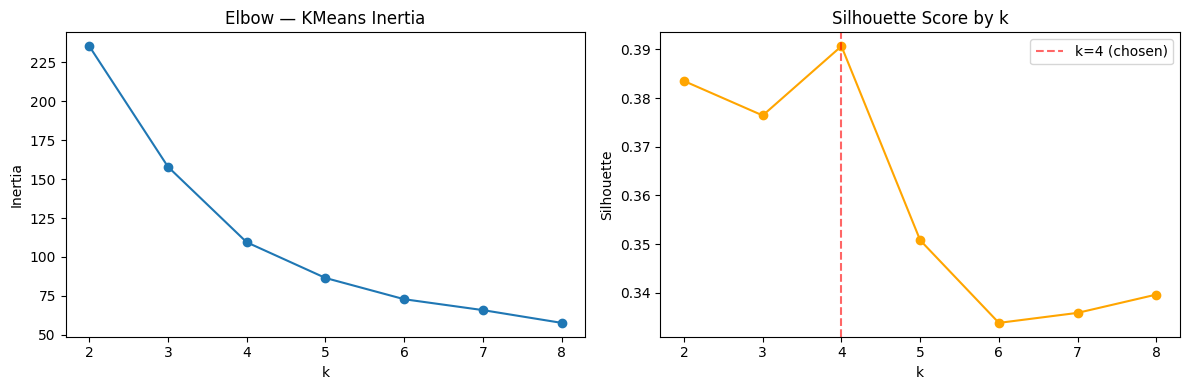

Silhouette — k=3: 0.376 | k=4: 0.391



RF feature importances:
win_rate              0.338
knockout_win_rate     0.257
avg_goals_scored      0.212
avg_goals_conceded    0.192
dtype: float64


In [7]:
# 'titles' excluded — derived from is_champion (target), data leakage
# 'gd_per_match' excluded — exact linear combination of avg_goals_scored - avg_goals_conceded
# Note: win_rate ↔ avg_goals_scored corr=0.88; kept because they measure distinct dimensions
#       (overall success vs offensive firepower — a team can win defensively with low scoring)
ML_FEATURES = [
    'win_rate',
    'avg_goals_scored',
    'avg_goals_conceded',
    'knockout_win_rate',
]

X = fact_team_historical_stats[ML_FEATURES].copy()
y = fact_team_historical_stats['is_champion']

# Clustering adds 'titles' — valid for unsupervised grouping, separates champions
# from strong non-champions that cluster together on performance stats alone
CLUSTER_FEATURES = ML_FEATURES + ['titles']
X_cluster = fact_team_historical_stats[CLUSTER_FEATURES].copy()
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# Validate k using cluster features
from sklearn.metrics import silhouette_score
inertias, silhouettes = [], []
for k in range(2, 9):
    _km = KMeans(n_clusters=k, random_state=42, n_init=10)
    _labels = _km.fit_predict(X_cluster_scaled)
    inertias.append(_km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, _labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(2, 9), inertias, 'o-')
ax1.set(title='Elbow — KMeans Inertia', xlabel='k', ylabel='Inertia')
ax2.plot(range(2, 9), silhouettes, 'o-', color='orange')
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 (chosen)')
ax2.set(title='Silhouette Score by k', xlabel='k', ylabel='Silhouette')
ax2.legend()
plt.tight_layout()
plt.show()
print(f"Silhouette — k=3: {silhouettes[1]:.3f} | k=4: {silhouettes[2]:.3f}")

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# PCA for visualization (5 features including titles)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_cluster_scaled)

# RF for champion_probability — in-sample, ML_FEATURES only (titles excluded: leakage for RF)
# In-sample is intentional: we want a narrative 'champion profile score', not an OOF classifier
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(X, y)
print('\nRF feature importances:')
print(pd.Series(rf_full.feature_importances_, index=ML_FEATURES).sort_values(ascending=False).round(3))

In [8]:
fact_team_ml_features = fact_team_historical_stats[['Team', 'titles', 'is_champion']].copy()
fact_team_ml_features['cluster'] = clusters
fact_team_ml_features['pca1'] = pca_result[:, 0]
fact_team_ml_features['pca2'] = pca_result[:, 1]

# Champion probability: in-sample RF score — measures similarity to champion profile
# All 8 historical champions score ≥ 0.66; non-champions reflect their historical strength
fact_team_ml_features['champion_probability'] = rf_full.predict_proba(X)[:, 1].round(3)

# Derive cluster labels: sort by mean titles so the champions cluster is always correctly named
cluster_stats = (
    fact_team_ml_features
    .merge(fact_team_historical_stats[['Team', 'win_rate']], on='Team')
    .groupby('cluster')[['titles', 'win_rate']]
    .mean()
    .sort_values('titles', ascending=False)
)
PROFILE_NAMES = ['World Cup Champions', 'Elite Contenders', 'Strong Nations', 'Emerging Teams']
cluster_rank = dict(zip(cluster_stats.index, PROFILE_NAMES))
fact_team_ml_features['team_profile'] = fact_team_ml_features['cluster'].map(cluster_rank)

# Include cluster-defining features for Power BI interpretability / scatter tooltips
fact_team_ml_features = fact_team_ml_features.merge(
    fact_team_historical_stats[['Team'] + ML_FEATURES],
    on='Team', how='left'
)

fact_team_ml_features.sort_values('champion_probability', ascending=False)[
    ['Team', 'champion_probability', 'titles', 'team_profile',
     'win_rate', 'knockout_win_rate', 'avg_goals_scored', 'avg_goals_conceded']
].head(15)

,Team,champion_probability,titles,team_profile,win_rate,knockout_win_rate,avg_goals_scored,avg_goals_conceded
8,Brazil,0.935,5,World Cup Champions,0.692982,0.688889,2.078947,0.947368
27,Germany,0.920,4,World Cup Champions,0.642857,0.700000,2.071429,1.160714
38,Italy,0.905,4,World Cup Champions,0.554217,0.741935,1.542169,0.927711
2,Argentina,0.880,3,World Cup Champions,0.602273,0.655172,1.727273,1.147727
26,France,0.805,2,World Cup Champions,0.561644,0.700000,1.863014,1.164384
68,Spain,0.740,1,Elite Contenders,0.477612,0.470588,1.611940,1.119403
25,England,0.710,1,Elite Contenders,0.445946,0.458333,1.405405,0.918919
78,Uruguay,0.660,2,Elite Contenders,0.440678,0.388889,1.508475,1.288136
16,Croatia,0.370,0,Elite Contenders,0.566667,0.750000,1.433333,1.100000
46,Netherlands,0.230,0,Elite Contenders,0.563636,0.454545,1.745455,0.945455


## 8. Visualizations

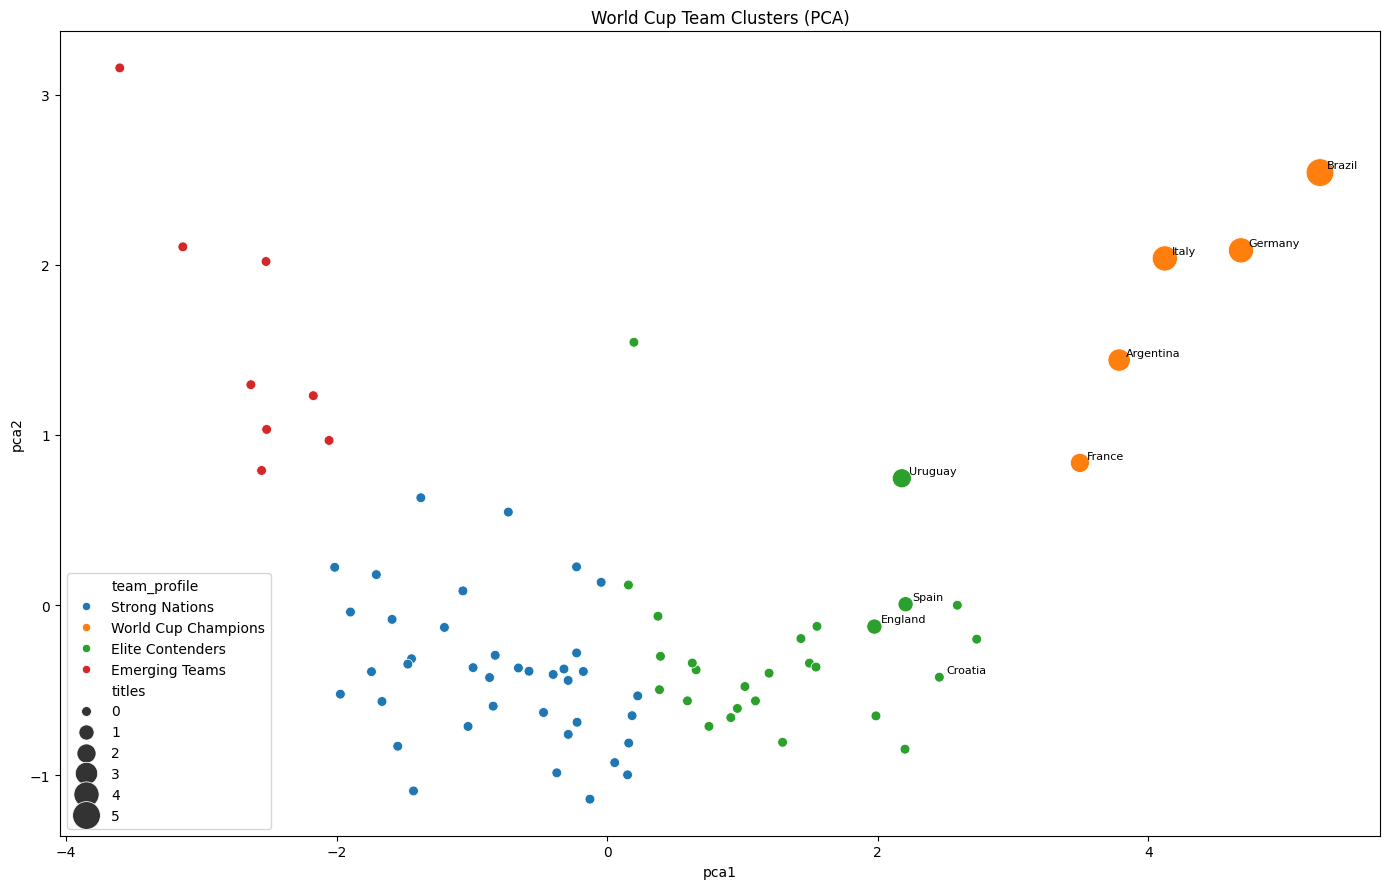

In [9]:
# Cluster scatter plot — teams with titles or high champion_probability annotated
fig, ax = plt.subplots(figsize=(14, 9))
sns.scatterplot(
    data=fact_team_ml_features,
    x='pca1', y='pca2',
    hue='team_profile',
    size='titles',
    sizes=(50, 400),
    ax=ax,
)
notable = fact_team_ml_features[
    (fact_team_ml_features['titles'] >= 1) |
    (fact_team_ml_features['champion_probability'] >= 0.3)
]
for _, row in notable.iterrows():
    ax.annotate(
        row['Team'],
        (row['pca1'], row['pca2']),
        fontsize=8,
        textcoords='offset points',
        xytext=(5, 3),
    )
ax.set_title('World Cup Team Clusters (PCA)')
plt.tight_layout()
plt.show()

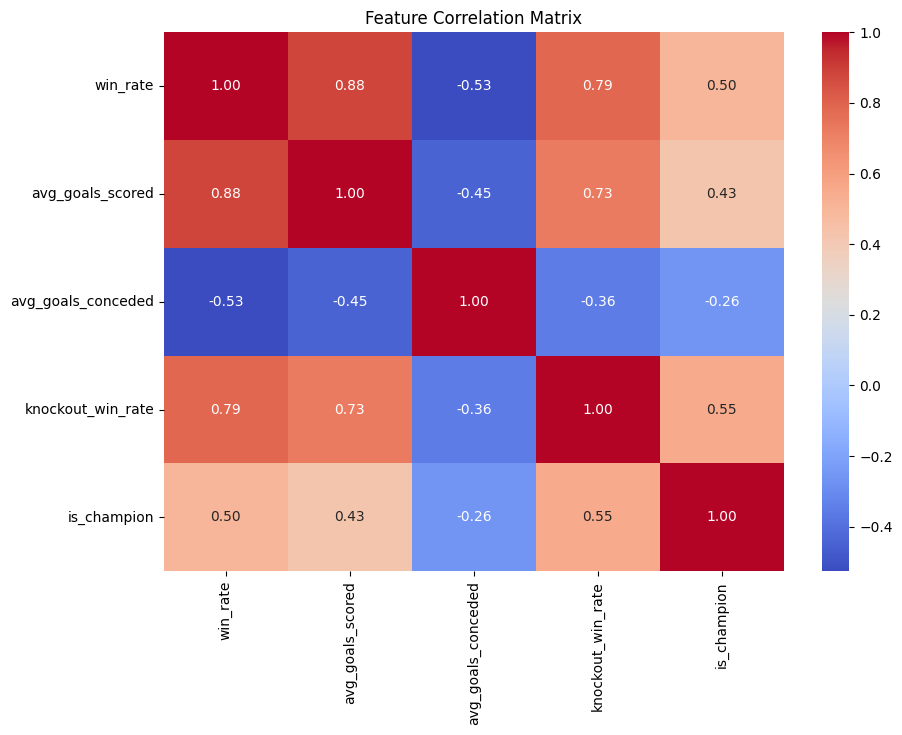

In [10]:
# Feature correlation matrix
corr = fact_team_historical_stats[ML_FEATURES + ['is_champion']].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [11]:
# PCA feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=CLUSTER_FEATURES,
    columns=['PCA1', 'PCA2']
).round(3)
print(loadings.sort_values('PCA1', ascending=False))

                     PCA1   PCA2
win_rate            0.524 -0.067
avg_goals_scored    0.497 -0.070
knockout_win_rate   0.485  0.216
titles              0.362  0.607
avg_goals_conceded -0.336  0.758


## 9. Export

In [12]:
import os
os.makedirs('../data/analytics/notebooks', exist_ok=True)

fact_team_historical_stats.to_csv(
    '../data/analytics/notebooks/fact_team_historical_stats.csv', index=False
)
fact_team_year_stage_stats.to_csv(
    '../data/analytics/notebooks/fact_team_year_stage_stats.csv', index=False
)
fact_modern_team_stats.to_csv(
    '../data/analytics/notebooks/fact_modern_team_stats.csv', index=False
)
fact_team_ml_features.to_csv(
    '../data/analytics/notebooks/fact_team_ml_features.csv', index=False
)

print('Exported:')
print(f'  fact_team_historical_stats  → {len(fact_team_historical_stats)} rows')
print(f'  fact_team_year_stage_stats  → {len(fact_team_year_stage_stats)} rows')
print(f'  fact_modern_team_stats      → {len(fact_modern_team_stats)} rows')
print(f'  fact_team_ml_features       → {len(fact_team_ml_features)} rows')

Exported:
  fact_team_historical_stats  → 81 rows
  fact_team_year_stage_stats  → 942 rows
  fact_modern_team_stats      → 33 rows
  fact_team_ml_features       → 81 rows
